In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mrl_trace import paths
from mrl_trace.stats import bootstrap_ci

# QUICK=True re-runs a fast, few-seed version of an experiment in-kernel (serial, no Pool);
# the default (QUICK=False) REPLAYS the committed 20-seed grid so every figure renders
# instantly and deterministically. The full sweeps are documented as `--full` shell
# commands in the last cell.
QUICK = False

GREEN, INDIGO, RED, GOLD, GREY = "#3aa07a", "#2f4b8f", "#c0392b", "#e0a93b", "#9aa6b2"
INK = "#2b2b2b"

def _clean(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.set_axisbelow(True); ax.grid(True, color="0.88", lw=0.5)

def _running(x, win=120):
    x = np.asarray(x, float)
    if len(x) < win:
        return x
    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[win:] - c[:-win]) / win

print("data/results:", paths.results_dir())

data/results: C:\Users\User\git\mrl-trace\data\results


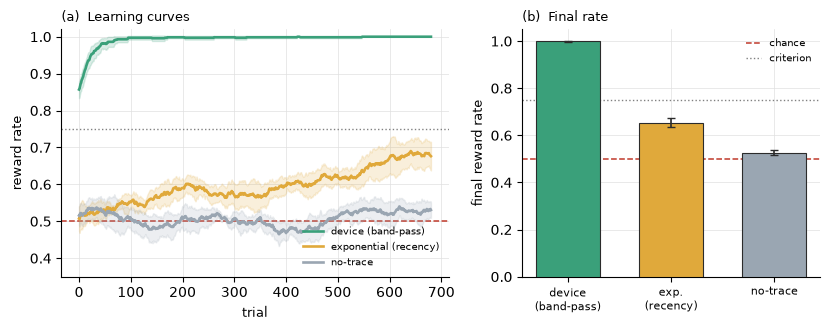

pre-registered criteria: {'H1': 'PASS', 'H2': 'PASS', 'H3': 'PASS', 'K1': 'fail'}
  device   : final 0.999  CI [0.998, 1.000]
  abstract : final 0.654  CI [0.636, 0.674]
  no_trace : final 0.526  CI [0.517, 0.537]


In [2]:
if QUICK:
    from mrl_trace.deep import run_dms_all
    d = run_dms_all(seeds=4, trials=800)
else:
    d = paths.load_result("exp12_dms.npy")

order = ["device", "abstract", "no_trace"]
disp = {"device": "device (band-pass)", "abstract": "exponential (recency)", "no_trace": "no-trace"}
cols = {"device": GREEN, "abstract": GOLD, "no_trace": GREY}
chance, crit = d["chance"], d["crit"]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(8.4, 3.4),
                               gridspec_kw={"width_ratios": [1.3, 1.0]})

# (a) learning curves with 95% CI band over seeds (from the per-seed raw traces)
raw = d.get("raw")
for k in order:
    if raw is not None:
        seeds = np.apply_along_axis(_running, 1, np.asarray(raw[k]))  # (B, T')
        m = seeds.mean(0); se = seeds.std(0) / np.sqrt(seeds.shape[0])
        t = np.arange(len(m))
        axA.fill_between(t, m - 1.96 * se, m + 1.96 * se, color=cols[k], alpha=0.18, zorder=2)
        axA.plot(t, m, color=cols[k], lw=1.9, label=disp[k], zorder=3)
    else:
        axA.plot(_running(d["curves"][k]), color=cols[k], lw=1.9, label=disp[k])
axA.axhline(chance, color=RED, ls="--", lw=1.1, zorder=1)
axA.axhline(crit, color="0.5", ls=":", lw=1.0, zorder=1)
axA.set_xlabel("trial", fontsize=9.5); axA.set_ylabel("reward rate", fontsize=9.5)
axA.set_ylim(0.35, 1.02); axA.set_title("(a)  Learning curves", fontsize=9.5, loc="left")
axA.legend(fontsize=7.2, loc="lower right", frameon=False); _clean(axA)

# (b) final bars with bootstrap 95% CI
x = np.arange(len(order))
means = [float(np.mean(d["finals"][k])) for k in order]
lo = [means[i] - d["ci"][k][0] for i, k in enumerate(order)]
hi = [d["ci"][k][1] - means[i] for i, k in enumerate(order)]
axB.bar(x, means, color=[cols[k] for k in order], edgecolor=INK, lw=0.8, width=0.62, zorder=3)
axB.errorbar(x, means, yerr=[lo, hi], fmt="none", ecolor=INK, elinewidth=1.2, capsize=3, zorder=4)
axB.axhline(chance, color=RED, ls="--", lw=1.1, zorder=1, label="chance")
axB.axhline(crit, color="0.5", ls=":", lw=1.0, zorder=1, label="criterion")
axB.legend(fontsize=7.0, loc="upper right", frameon=False, handlelength=1.6)
axB.set_xticks(x); axB.set_xticklabels(["device\n(band-pass)", "exp.\n(recency)", "no-trace"], fontsize=7.8)
axB.set_ylim(0, 1.05); axB.set_ylabel("final reward rate", fontsize=9.5)
axB.set_title("(b)  Final rate", fontsize=9.5, loc="left"); _clean(axB)
fig.tight_layout(); plt.show()

print("pre-registered criteria:", {k: ("PASS" if v else "fail") for k, v in d["criteria"].items()})
for k in order:
    print(f"  {k:9s}: final {means[order.index(k)]:.3f}  CI [{d['ci'][k][0]:.3f}, {d['ci'][k][1]:.3f}]")

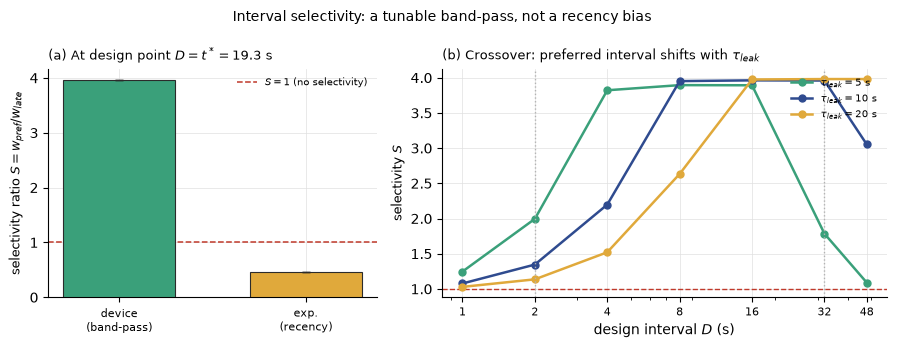

pre-registered criteria: {'P1': 'PASS', 'P2': 'PASS', 'P3': 'PASS', 'P4': 'PASS'}
  device S = 3.96  CI [3.96, 3.97]  (P1: CI lower > 1)
  exp.   S = 0.46  CI [0.45, 0.47]  (P2: CI upper < 1)
  t*(tau_leak): {5.0: 10.0, 10.0: 19.3, 20.0: 35.1}


In [3]:
if QUICK:
    from mrl_trace.selectivity import run_interval_selectivity
    d = run_interval_selectivity(seeds=4, trials=400)
else:
    d = paths.load_result("exp10_interval.npy")

dev_S, exp_S = np.asarray(d["dev_S"]), np.asarray(d["exp_S"])
dev_ci, exp_ci = d["dev_ci"], d["exp_ci"]
taus = list(np.asarray(d["taus"], float))
D_grid = np.asarray(d["D_grid"], float)
Scurve = d["Scurve"]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.2, 3.5),
                               gridspec_kw={"width_ratios": [0.85, 1.15]})

# (a) design-point selectivity: device band-pass (S>1) vs exponential recency (S<1)
xs = np.arange(2)
mA = [dev_S.mean(), exp_S.mean()]
loA = [mA[0] - dev_ci[0], mA[1] - exp_ci[0]]
hiA = [dev_ci[1] - mA[0], exp_ci[1] - mA[1]]
axA.bar(xs, mA, color=[GREEN, GOLD], edgecolor=INK, lw=0.8, width=0.6, zorder=3)
axA.errorbar(xs, mA, yerr=[loA, hiA], fmt="none", ecolor=INK, elinewidth=1.2, capsize=3, zorder=4)
axA.axhline(1.0, color=RED, ls="--", lw=1.1, zorder=1, label="$S=1$ (no selectivity)")
axA.set_xticks(xs); axA.set_xticklabels(["device\n(band-pass)", "exp.\n(recency)"], fontsize=8)
axA.set_ylabel("selectivity ratio $S = w_{pref}/w_{late}$", fontsize=9)
axA.set_title(f"(a) At design point $D=t^*={d['D0']:.1f}$ s", fontsize=9.5, loc="left")
axA.legend(fontsize=7.2, loc="upper right", frameon=False); _clean(axA)

# (b) S(D) crossover: the preferred interval shifts right with tau_leak
tcol = {5.0: GREEN, 10.0: INDIGO, 20.0: GOLD}
for tl in taus:
    axB.plot(D_grid, np.asarray(Scurve[tl], float), "o-", color=tcol.get(tl, GREY),
             lw=1.8, ms=5, label=rf"$\tau_{{leak}}={tl:g}$ s")
axB.axhline(1.0, color=RED, ls="--", lw=1.0, zorder=1)
axB.axvline(2, color="0.7", ls=":", lw=1.0); axB.axvline(32, color="0.7", ls=":", lw=1.0)
axB.set_xscale("log"); axB.set_xticks([1, 2, 4, 8, 16, 32, 48])
axB.set_xticklabels([1, 2, 4, 8, 16, 32, 48], fontsize=8)
axB.set_xlabel("design interval $D$ (s)"); axB.set_ylabel("selectivity $S$", fontsize=9)
axB.set_title("(b) Crossover: preferred interval shifts with $\\tau_{leak}$", fontsize=9.5, loc="left")
axB.legend(fontsize=7.5, frameon=False, loc="upper right"); _clean(axB)
fig.suptitle("Interval selectivity: a tunable band-pass, not a recency bias", fontsize=10)
fig.tight_layout(); plt.show()

crit = {k: bool(d[k]) for k in ("P1", "P2", "P3", "P4")}
print("pre-registered criteria:", {k: ("PASS" if v else "fail") for k, v in crit.items()})
print(f"  device S = {dev_S.mean():.2f}  CI [{dev_ci[0]:.2f}, {dev_ci[1]:.2f}]  (P1: CI lower > 1)")
print(f"  exp.   S = {exp_S.mean():.2f}  CI [{exp_ci[0]:.2f}, {exp_ci[1]:.2f}]  (P2: CI upper < 1)")
print("  t*(tau_leak):", {k: round(v, 1) for k, v in d["tstar"].items()})

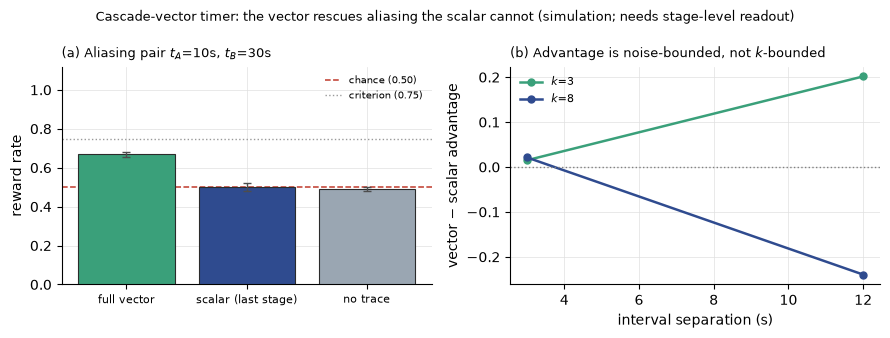

pre-registered criteria: {'H1': 'fail', 'H2': 'PASS', 'H3': 'PASS', 'K1': 'fail'}
  vector   : reward rate 0.668  CI [0.655, 0.682]
  scalar   : reward rate 0.502  CI [0.481, 0.524]
  no_trace : reward rate 0.491  CI [0.478, 0.502]


In [4]:
if QUICK:
    from mrl_trace.selectivity import run_vector_timer
    d = run_vector_timer(seeds=4, trials=600, quick=True)
else:
    d = paths.load_result("exp20_vector_timer.npy")

fin, ci = d["finals"], d["ci"]
tA, tB = d.get("tA", 10.5), d.get("tB", 30.5)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(9, 3.4))

# (a) aliasing-rescue at the measured scalar-aliasing pair
order = ["vector", "scalar", "no_trace"]
vcols = {"vector": GREEN, "scalar": INDIGO, "no_trace": GREY}
lab = {"vector": "full vector", "scalar": "scalar (last stage)", "no_trace": "no trace"}
m = [float(np.mean(fin[k])) for k in order]
lo = [m[i] - ci[order[i]][0] for i in range(3)]; hi = [ci[order[i]][1] - m[i] for i in range(3)]
axA.bar(np.arange(3), m, color=[vcols[k] for k in order], edgecolor=INK, lw=0.8,
        yerr=np.vstack([lo, hi]), capsize=3, error_kw=dict(lw=1, ecolor="0.3"), zorder=3)
axA.axhline(d.get("chance", 0.5), color=RED, ls="--", lw=1.1, zorder=1, label="chance (0.50)")
axA.axhline(d.get("crit", 0.75), color="0.6", ls=":", lw=1.0, zorder=1, label="criterion (0.75)")
axA.set_xticks(range(3)); axA.set_xticklabels([lab[k] for k in order], fontsize=8)
axA.set_ylabel("reward rate"); axA.set_ylim(0, 1.12)
axA.set_title(f"(a) Aliasing pair $t_A$={tA:.0f}s, $t_B$={tB:.0f}s", fontsize=9.5, loc="left")
axA.legend(fontsize=7, frameon=False, loc="upper right", handlelength=1.6); _clean(axA)

# (b) vector-minus-scalar advantage vs separation x k (noise- not k-bounded)
seps = list(np.asarray(d["seps"], float)); ks = list(np.asarray(d["ks"], int))
kcol = {k: c for k, c in zip(ks, [GREEN, INDIGO, GOLD])}
for k in ks:
    adv = [d["sweep"][f"{float(s)}_{k}"]["vector"] - d["sweep"][f"{float(s)}_{k}"]["scalar"]
           for s in seps]
    axB.plot(seps, adv, "o-", color=kcol[k], lw=1.8, ms=5, label=f"$k$={k}")
axB.axhline(0, color="0.5", ls=":", lw=1.0)
axB.set_xlabel("interval separation (s)"); axB.set_ylabel("vector $-$ scalar advantage")
axB.set_title("(b) Advantage is noise-bounded, not $k$-bounded", fontsize=9.5, loc="left")
axB.legend(fontsize=8, frameon=False); _clean(axB)
fig.suptitle("Cascade-vector timer: the vector rescues aliasing the scalar cannot "
             "(simulation; needs stage-level readout)", fontsize=9.5)
fig.tight_layout(); plt.show()

print("pre-registered criteria:", {k: ("PASS" if v else "fail") for k, v in d["criteria"].items()})
for k in order:
    print(f"  {k:9s}: reward rate {m[order.index(k)]:.3f}  CI [{ci[k][0]:.3f}, {ci[k][1]:.3f}]")

In [5]:
# Uncomment to launch the full sweeps as subprocesses (streamed; heavy -- minutes each):
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "mrl_trace.selectivity", "--exp10", "--exp20", "--full"])
print("see the markdown above for the full-scale commands")

see the markdown above for the full-scale commands
